In [1]:
import pandas as pd

df = pd.read_csv('../data/q2_customers.csv')

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

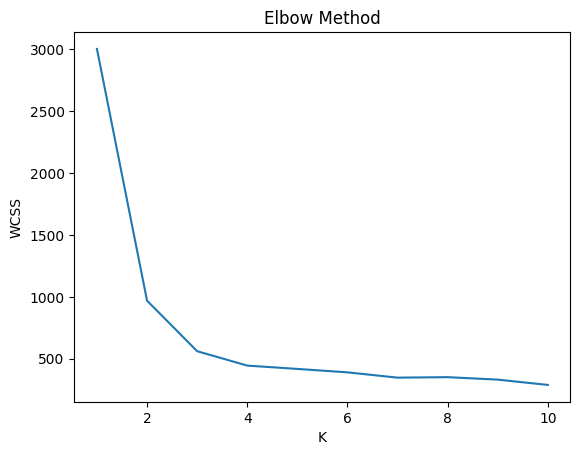

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(X)

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [9]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

In [12]:
pca.explained_variance_ratio_

array([0.83560354, 0.05568764])

In [13]:
pd.DataFrame(pca.components_, columns=df.columns[:-1])

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
1,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


In [14]:
pd.DataFrame(pca.components_, columns=df.columns[:-1])

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
1,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


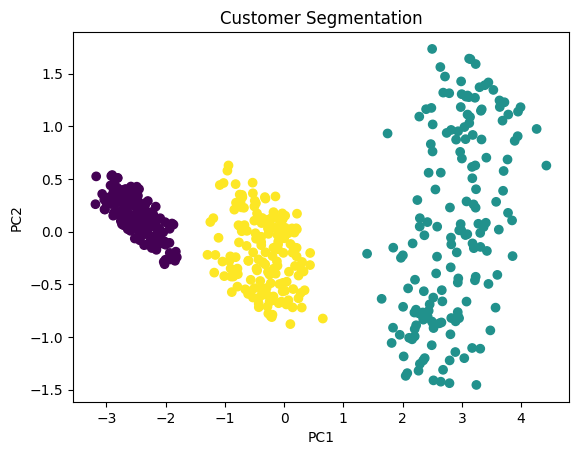

In [15]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segmentation')
plt.show()